# Task-1

In [1]:
import time
import random
import matplotlib.pyplot as plt

def merge_sort(arr):
    if len(arr) <= 1:
        return arr
    
    mid = len(arr)//2
    left = merge_sort(arr[:mid])
    right = merge_sort(arr[mid:])
    
    return merge(left, right)

def merge(left, right):
    result = []
    i = j = 0
    
    while i < len(left) and j < len(right):
        if left[i] < right[j]:
            result.append(left[i])
            i += 1
        else:
            result.append(right[j])
            j += 1
    
    result.extend(left[i:])
    result.extend(right[j:])
    
    return result

In [2]:
sizes = [100, 500, 1000, 2000]
times = []

for n in sizes:
    arr = [random.randint(1,1000) for _ in range(n)]
    
    start = time.time()
    merge_sort(arr)
    times.append(time.time() - start)

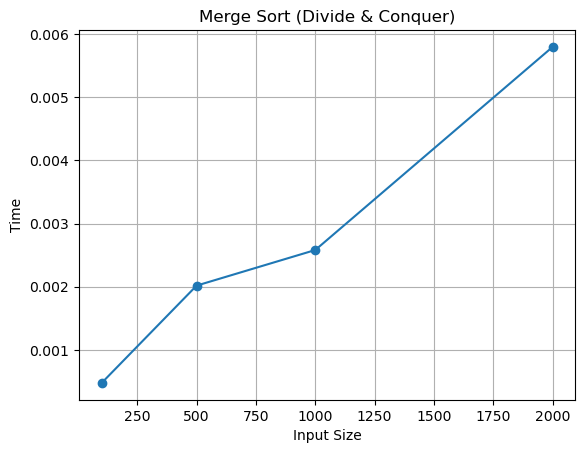

In [3]:
plt.plot(sizes, times, marker='o')
plt.xlabel("Input Size")
plt.ylabel("Time")
plt.title("Merge Sort (Divide & Conquer)")
plt.grid()
plt.show()

# Task-2

In [4]:
import time
import random
import matplotlib.pyplot as plt

In [5]:
def bubble_sort(arr):
    n = len(arr)
    for i in range(n):
        for j in range(0, n-i-1):
            if arr[j] > arr[j+1]:
                arr[j], arr[j+1] = arr[j+1], arr[j]
    return arr

In [6]:
def merge_sort(arr):
    if len(arr) <= 1:
        return arr
    
    mid = len(arr)//2
    left = merge_sort(arr[:mid])
    right = merge_sort(arr[mid:])
    
    return merge(left, right)

def merge(left, right):
    result = []
    i = j = 0
    
    while i < len(left) and j < len(right):
        if left[i] < right[j]:
            result.append(left[i])
            i += 1
        else:
            result.append(right[j])
            j += 1
    
    result.extend(left[i:])
    result.extend(right[j:])
    
    return result

In [7]:
sizes = [100, 300, 500, 800]

In [8]:
bubble_times = []
merge_times = []
builtin_times = []

for n in sizes:
    arr = [random.randint(1,1000) for _ in range(n)]
    
    # Bubble Sort
    arr_copy = arr.copy()
    start = time.time()
    bubble_sort(arr_copy)
    bubble_times.append(time.time() - start)
    
    # Merge Sort
    arr_copy = arr.copy()
    start = time.time()
    merge_sort(arr_copy)
    merge_times.append(time.time() - start)
    
    # Built-in Sort
    arr_copy = arr.copy()
    start = time.time()
    sorted(arr_copy)
    builtin_times.append(time.time() - start)

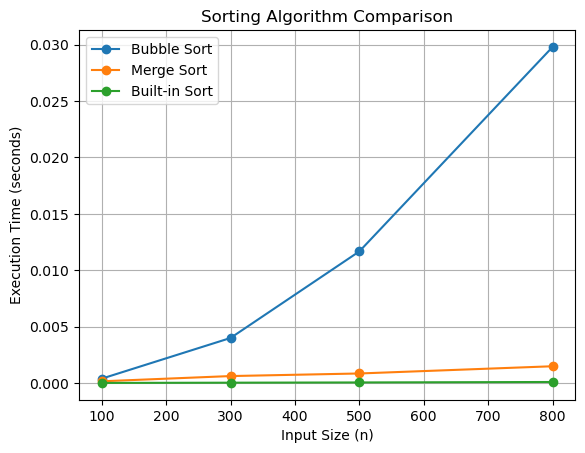

In [9]:
plt.plot(sizes, bubble_times, marker='o', label="Bubble Sort")
plt.plot(sizes, merge_times, marker='o', label="Merge Sort")
plt.plot(sizes, builtin_times, marker='o', label="Built-in Sort")

plt.xlabel("Input Size (n)")
plt.ylabel("Execution Time (seconds)")
plt.title("Sorting Algorithm Comparison")
plt.legend()
plt.grid()

plt.show()

# Task-3

In [15]:
# Task 3: Greedy Algorithm - Activity Selection

def activity_selection(start, finish):
    # Combine start and finish times
    activities = list(zip(start, finish))
    
    # Sort activities by finish time
    activities.sort(key=lambda x: x[1])
    
    selected = []
    
    # Select first activity
    selected.append(activities[0])
    last_finish = activities[0][1]
    
    # Select remaining activities
    for i in range(1, len(activities)):
        if activities[i][0] >= last_finish:
            selected.append(activities[i])
            last_finish = activities[i][1]
    
    return selected


# Input data
start = [1, 3, 0, 5, 8, 5]
finish = [2, 4, 6, 7, 9, 9]

# Run algorithm
result = activity_selection(start, finish)

# Print output (clean format)
print("Selected Activities:")
for act in result:
    print(f"({act[0]}, {act[1]})")

Selected Activities:
(1, 2)
(3, 4)
(5, 7)
(8, 9)


# Task 4

In [16]:
def fib_recursive(n):
    if n <= 1:
        return n
    return fib_recursive(n-1) + fib_recursive(n-2)

In [17]:
def fib_dp(n):
    dp = [0, 1]
    for i in range(2, n+1):
        dp.append(dp[i-1] + dp[i-2])
    return dp[n]

In [18]:
import time

sizes = [5, 10, 20, 30]

recursive_times = []
dp_times = []

for n in sizes:
    
    # Recursive
    start = time.time()
    fib_recursive(n)
    recursive_times.append(time.time() - start)
    
    # DP
    start = time.time()
    fib_dp(n)
    dp_times.append(time.time() - start)

In [19]:
for i in range(len(sizes)):
    print(f"n={sizes[i]} | Recursive={recursive_times[i]} | DP={dp_times[i]}")

n=5 | Recursive=8.821487426757812e-06 | DP=6.9141387939453125e-06
n=10 | Recursive=3.1948089599609375e-05 | DP=5.0067901611328125e-06
n=20 | Recursive=0.003590106964111328 | DP=5.7220458984375e-06
n=30 | Recursive=0.13797974586486816 | DP=7.152557373046875e-06


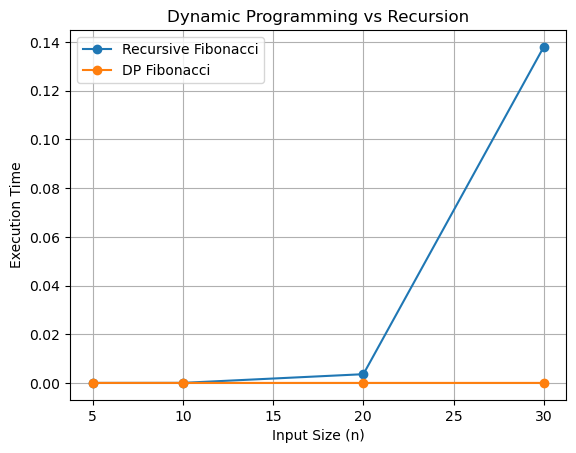

In [20]:
import matplotlib.pyplot as plt

plt.plot(sizes, recursive_times, marker='o', label="Recursive Fibonacci")
plt.plot(sizes, dp_times, marker='o', label="DP Fibonacci")

plt.xlabel("Input Size (n)")
plt.ylabel("Execution Time")
plt.title("Dynamic Programming vs Recursion")
plt.legend()
plt.grid()

plt.show()

# Task-5

In [21]:
import itertools

# Distance matrix
graph = [
    [0, 10, 15, 20],
    [10, 0, 35, 25],
    [15, 35, 0, 30],
    [20, 25, 30, 0]
]

n = len(graph)

# Function to calculate cost
def calculate_cost(path):
    cost = 0
    for i in range(len(path)-1):
        cost += graph[path[i]][path[i+1]]
    cost += graph[path[-1]][path[0]]  # return to start
    return cost

# TSP brute force
cities = list(range(n))
min_cost = float('inf')
best_path = None

for perm in itertools.permutations(cities[1:]):
    path = [0] + list(perm)
    cost = calculate_cost(path)
    
    if cost < min_cost:
        min_cost = cost
        best_path = path

print("Best Path:", best_path)
print("Minimum Cost:", min_cost)

Best Path: [0, 1, 3, 2]
Minimum Cost: 80
